# Code for HESS sensitivity for for annihilatting DM in the GC

In [1]:
from gammapy.data import DataStore
from gammapy.irf import Background3D

from scipy.interpolate import interp1d
import numpy as np

import math
import astropy
import os
import pandas as pd
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as cst

import matplotlib.pyplot as plt
import pylab
from operator import truediv

from scipy.optimize import fsolve
from scipy import signal
from scipy.integrate import quad, nquad, dblquad, simps, trapz

from gammapy.stats import WStatCountsStatistic
from gammapy.maps import Map, MapAxis
from gammapy.irf import EffectiveAreaTable2D, load_cta_irfs, EnergyDispersion2D, load_irf_dict_from_file
#from gammapy.maps import Map, MapAxis
from astropy.coordinates import SkyCoord

# Definig functions

In [2]:
def set_energy_bins(min_energy=0.15848931924611134,max_energy=100,nbins=70):#in TeV
    min_power = np.log10(min_energy) #-1.68#-1.68 #-1.68
    step = (np.log10(max_energy)-min_power)/nbins # 92 130
    # ~ print(step)
    intervals = []
    for count in range(0, nbins):#set 92 logarithmic bins between 10**min_power and 10**2 -> step = (log(max_energy)-log(min_energy))/92
        intervals.append([])
        #intervals are in TeV
        intervals[count].append((10**(min_power+count*step)))#emin
        intervals[count].append((10**(min_power+(count+1)*step)))#emax
    # ~ print(intervals)
    return intervals#return bg rate per energy bin, energy bins in TeV

In [3]:
def set_energy_bins(file,binmin,binmax):
    lines = []
    with open(file) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt(lines, names = True ,dtype = float)
    counts = []
    for line in data:
        counts_line = []
        for number in line:
            counts_line.append(number)
            # ~ print(data.dtype.names)
        counts.append(counts_line)
    B = np.array(counts)[binmin-1:binmax,2:]
    intervals = np.array(counts)[binmin-1:binmax,:2]
    
    return intervals, B

In [4]:
def get_effarea(filename):
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    eeff = data['ETeV']
    aeff = data['Aeffcm2']
    Aeff = interp1d(eeff, aeff,bounds_error=False, fill_value=0.)
    return eeff, Aeff

In [5]:
def J_regions(filename):
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = float)
    
    return data['Solid'],data['J'] # region name, solid angle, J-factor

In [6]:
def dNdE(spectra_name, mass): # for micrOMEGAs/model dependent data
    lines = []
    with open(spectra_name) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)


    massvals = data["mDM"]
    #index = np.where(np.abs( (massvals - mass) / mass) < 1.e-3)
    index = np.where(massvals == mass)
    Evals = data["E"][index]
    spectrum = data["dNdE"][index]
    #print("Evals",Evals)
    loadspec = interp1d(Evals, spectrum,bounds_error=False, fill_value=0.)# GeV x GeV-1
    E = np.array(sorted(set(Evals)))
    return E[0::round(len(E)/200)], loadspec # E dNdE [0:-1:round(len(mass_total)/20)]

In [7]:
def dNdE_prim(filename,mass,channel): # for Cirelli data
    Gamma = open(filename,'r')
    gamma_header = Gamma.readline().split()
    spectra = []
    for line in Gamma:
        numbers = line.split()
        numbers = [float(n) for n in numbers]
        spectra.append(numbers)

    Gamma.close()
    spectra = np.array(spectra)    
    data = pd.DataFrame(spectra,columns=gamma_header)
    
    #m = (np.abs( (data['mDM'] - mass) / mass) < 5.e-2)
    m = (data['MDM'] == mass)
    gamma = data[m]
    E = np.array(mass*np.power(10,gamma['Log[10,x]']))
    dN = np.array(gamma[channel])#.divide(np.log(10))
    dN = np.divide(dN,E*np.log(10))
 
    loadspec = interp1d(E, dN,bounds_error=False, fill_value=0.)# GeV x GeV-1
    E = np.array(sorted(set(E)))
    #print(len(E),round(len(E)/1000))
    return E[0::round(len(E)/200)], loadspec # GeV, GeV^-1 

In [8]:
def Ns_function(e, interpolarea, flux):#function to integrate ns. observation time is multiplied after return
    #e in TeV
    if(e <= 3e-2):#effective area energy limits (TeV)
        return 0
    if(e >= 1e2):
        return 0

    Ns = interpolarea(e)
    Ns *= (flux(e*1e3)*1e3)
    return Ns

In [9]:
def Ns_integral(mass, tobs, interval, interpolarea, flux, Evals):#Evals are the energy values used to interpolate flux
    # E in TeV
    integration_max = interval[1]
    integration_min = interval[0]
    if(interval[1] <= Evals[0]/1000):#integration range is below the valid flux range, return 0
        # ~ print('integration range is below the valid flux range, return 0')
        return 0
    if(interval[0] >= mass/1000):#integration range is above the max energy value, return 0
        # ~ print('integration range is above the max energy value, return 0')
        return 0
    if(interval[0] < Evals[0]/1000):#integration is valid, but the minimum has to be increased
        # ~ print('integration is valid, but the minimum has to be increased')
        integration_min = Evals[0]/1000
    if(interval[1] > mass/1000):#the integration is valid but the max value has to be reduced
        # ~ print('the integration is valid but the max value has to be reduced')
        integration_max = mass/1000
    result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))

    return result*tobs

In [10]:
def masses_list(filename_masses): # final version
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)

    masses_list = np.array(sorted(set(data['MDM'])))
    return masses_list# GeV

In [11]:
def Sigma_CA(filename_masses):
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    masses_list = np.array(sorted(set(data['MDM'])))
    sigma_CA = []
    for mass in masses_list:
        sigma = np.mean(np.array(data['SigmaV'][(data['MDM'] == mass)]))
        sigma_CA.append(sigma)
    #sigma_list = np.array(sorted(set(data['SigmaV'])))
    
    return np.array(sigma_CA)


In [12]:
def ID_limits(filename): # final version
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    sigma = np.array(data['SigmaV'])
    masses = np.array(data['mDM'])
    
    return masses, sigma

In [13]:
def S2(n_off,ns,alpha):
    delta = np.sqrt( (ns-alpha*n_off)**2. + 4.*ns*alpha*n_off/(alpha+1)  )
    S2 = n_off*( np.log( (2.*alpha*n_off/(ns+alpha*n_off+delta))**alpha * (2.*alpha*n_off/(-ns+alpha*n_off+delta)) ) - 0.5*(alpha+1.) ) + (alpha+1.)*((alpha-1.)*ns/(alpha+1.) + delta)/(2.*alpha)  
    return 2.*S2

In [14]:
def TS(n_off,ns,alpha):
    S = 0
    (a,b) = np.shape(n_off)
    (c,d) = np.shape(ns)
    if (c != a or d != b):
        print("Off and Signal data not compatible")
        return 0
    else:
        for region in range(b):
            for interval in range(a):
                off = n_off[interval,region]
                signal = ns[interval,region]
                if (off >= 1 and signal >= 1):
                    currentS = S2(off,signal,alpha)
                    if(currentS < 0):
                        print('currentS is negative')
                    else:
                        S += currentS
                    
                    if(S<0):
                        print('s is negative, somehow', S)
            
    return S

# Getting IRF's and data from 254 h for HESS inner GC (2016) 

In [15]:
# getting off counts
Count_file = 'HESS 2016/HESS ROI OFF counts.dat'



In [16]:
intervals, B = set_energy_bins(Count_file,6,75)

In [17]:
B

array([[1.160e+02, 2.590e+02, 3.520e+02, 4.370e+02, 5.520e+02, 6.050e+02,
        6.740e+02],
       [1.910e+02, 4.220e+02, 5.490e+02, 7.540e+02, 8.520e+02, 1.063e+03,
        1.081e+03],
       [2.550e+02, 5.460e+02, 7.490e+02, 9.340e+02, 1.120e+03, 1.286e+03,
        1.409e+03],
       [3.330e+02, 6.970e+02, 9.720e+02, 1.166e+03, 1.464e+03, 1.631e+03,
        1.755e+03],
       [3.540e+02, 7.560e+02, 1.043e+03, 1.327e+03, 1.524e+03, 1.769e+03,
        1.873e+03],
       [3.680e+02, 8.320e+02, 1.152e+03, 1.467e+03, 1.753e+03, 2.054e+03,
        2.131e+03],
       [4.510e+02, 8.440e+02, 1.185e+03, 1.510e+03, 1.742e+03, 2.027e+03,
        2.259e+03],
       [3.920e+02, 7.890e+02, 1.185e+03, 1.425e+03, 1.742e+03, 1.906e+03,
        2.159e+03],
       [3.920e+02, 7.580e+02, 1.036e+03, 1.375e+03, 1.575e+03, 1.894e+03,
        2.011e+03],
       [3.410e+02, 7.280e+02, 9.650e+02, 1.318e+03, 1.565e+03, 1.818e+03,
        1.861e+03],
       [3.410e+02, 6.720e+02, 9.190e+02, 1.150e+03, 1.324e+0

In [18]:
intervals

array([[  0.15848932,   0.17378008],
       [  0.17378008,   0.19054607],
       [  0.19054607,   0.20892961],
       [  0.20892961,   0.22908677],
       [  0.22908677,   0.25118864],
       [  0.25118864,   0.27542287],
       [  0.27542287,   0.30199517],
       [  0.30199517,   0.33113112],
       [  0.33113112,   0.36307805],
       [  0.36307805,   0.39810717],
       [  0.39810717,   0.43651583],
       [  0.43651583,   0.47863009],
       [  0.47863009,   0.52480746],
       [  0.52480746,   0.57543994],
       [  0.57543994,   0.63095734],
       [  0.63095734,   0.69183097],
       [  0.69183097,   0.75857758],
       [  0.75857758,   0.83176377],
       [  0.83176377,   0.91201084],
       [  0.91201084,   1.        ],
       [  1.        ,   1.0964782 ],
       [  1.0964782 ,   1.20226443],
       [  1.20226443,   1.31825674],
       [  1.31825674,   1.44543977],
       [  1.44543977,   1.58489319],
       [  1.58489319,   1.73780083],
       [  1.73780083,   1.90546072],
 

In [19]:
area_filename = 'HESS 2016/HESS_EffA_off0.7_18z.dat'
eeff,Aeff = get_effarea(area_filename)

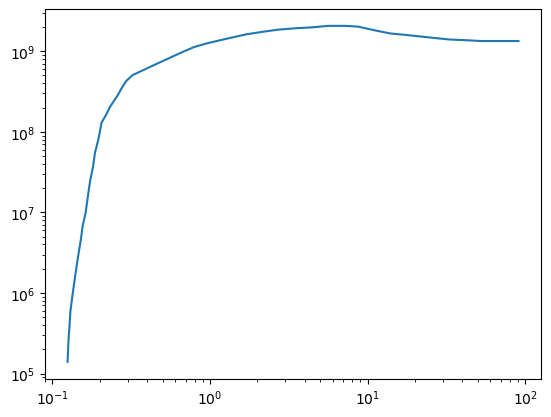

In [20]:
plt.plot(eeff,Aeff(eeff))
plt.xscale('log')
plt.yscale('log')

In [21]:
J_file = "J_GC_EinastoCTA.dat"
#J_file = 'J_GC_data.dat'
[solid,J] = J_regions(J_file)
print(J)

[2.867e+20 5.164e+20 6.360e+20 7.350e+20 7.886e+20 8.408e+20 8.743e+20]


# Sensitivity to primary channels

In [33]:
filename_prim = "AtProduction_gammas.dat"


masses = masses_list(filename_prim)

print(masses[20:])



[   160    180    200    220    240    260    280    300    330    360
    400    450    500    550    600    650    700    750    800    900
   1000   1100   1200   1300   1500   1700   2000   2500   3000   4000
   5000   6000   7000   8000   9000  10000  12000  15000  20000  30000
  50000 100000]


In [40]:
tobs = 254*3600
significance = 2.71
alpha = 1.#/6.

f = open('HESS_tt.dat','w')
f.write('# Indirection Detection Limits\n')
f.write('# Spectrum: PPPC4 tt\n')
f.write('#Units: DM mass = GeV, <sigma v> = cm^3 s⁻1\n')
f.write('mDM SigmaV \n')

J0 = 1e20
sigmav0 = 3e-26
sigma_range = np.logspace(-26,-22,60)**2.
nSV = len(sigma_range)

HESS_sensitivity_tt = []

for mass in masses[23:]:
    E, loadspec = dNdE_prim(filename_prim,mass,'t')
    C = sigmav0*(8.*np.pi*mass**2.)**-1. *J0

    Nr = []
    for bin in range(len(intervals)):
        Nr.append([C*Ns_integral(mass, tobs, intervals[bin], Aeff, loadspec, E)])

    Nr = np.array(Nr) 
    #Nr = DispersionMap.T@Nt
    Ns = J0**(-1.)*  Nr*J 
    
    TS_range = np.zeros(nSV)
    for i in range(nSV):
        #print(sigma_range[i])
        TS_range[i] = TS(B,(np.sqrt(sigma_range[i])/sigmav0)*Ns,alpha)    
    #print(mass,TS_range)
    SigmaV = interp1d(TS_range,sigma_range)  
    #print(TS_range)
    sigmalim = np.sqrt(SigmaV(significance))
    HESS_sensitivity_tt.append(sigmalim)
    print(mass,sigmalim)
    f.write(str(mass)+' '+str(sigmalim)+'\n')
    
f.close()



220 7.258031598934382e-23
240 3.159631211432909e-23
260 1.6753496263484837e-23
280 9.294711905510564e-24
300 5.85201908508045e-24
330 3.2269005961305294e-24
360 2.1391865633449845e-24
400 1.4028127961634223e-24


/tmp/ipykernel_5486/647339345.py:17: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


450 9.662958255188645e-25
500 7.35567818560245e-25
550 5.967931339948131e-25
600 5.0563415141498215e-25
650 4.426266987167045e-25
700 3.9343488068995773e-25
750 3.5514432467598687e-25
800 3.2568205528601886e-25
900 2.8059948086688676e-25
1000 2.4993220885414193e-25
1100 2.272354723026276e-25
1200 2.1006270933970016e-25
1300 1.9650504881004682e-25
1500 1.7741581033177154e-25
1700 1.6441599217760876e-25
2000 1.5156334594479246e-25
2500 1.4042685247403586e-25
3000 1.3535222992114592e-25
4000 1.3315431991877665e-25
5000 1.3586216171090218e-25
6000 1.4080384439574406e-25
7000 1.4678538606472846e-25
8000 1.536074440734991e-25
9000 1.6089718687299379e-25
10000 1.6855155815998063e-25
12000 1.8424334006710376e-25
15000 2.089117516517556e-25
20000 2.5166094919265594e-25
30000 3.411021538475354e-25
50000 5.336829063697449e-25
100000 1.0828492735543539e-24


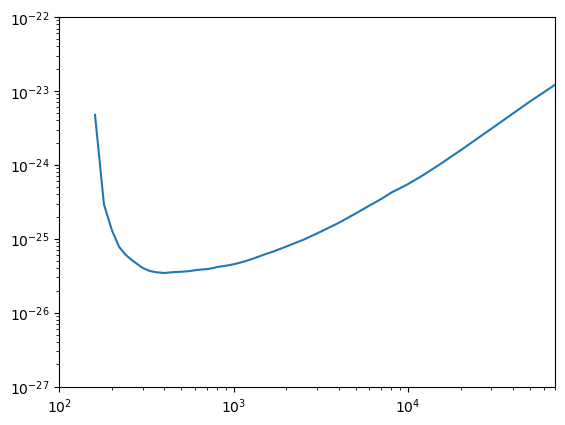

In [26]:
#plt.plot(masses[22:],CTA_sensitivity_WW)
#plt.plot(masses[22:],CTA_sensitivity_ZZ)
plt.plot(masses[20:],HESS_sensitivity_ee)
#plt.plot(mass_range[11:],HESS_sensitivity_tautau)
#plt.plot(mass_range[11:],HESS_sensitivity_bb)

#plt.xlim(5e2,5e3)
plt.ylim(1e-27,1e-22)
plt.xlim(1e2,7e4)
plt.xscale('log')
plt.yscale('log')

In [43]:
HESS_massW, HESS_sigmaW = ID_limits('HESS_official_WW254h.dat')
HESS_masstau, HESS_sigmatau = ID_limits('HESS_official_tautau254h.dat')
HESS_massbb, HESS_sigmabb = ID_limits('HESS_official_bb254h.dat')

massW, sigmaW = ID_limits('HESS_WW.dat')
masstau, sigmatau = ID_limits('HESS_tautau.dat')
massbb, sigmabb = ID_limits('HESS_bb.dat')



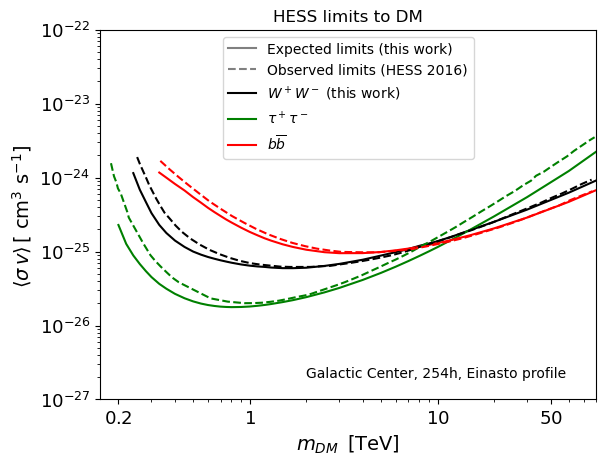

In [65]:
plt.plot([],[],label = 'Expected limits (this work)',linestyle='solid',color='gray')
plt.plot([],[],label = 'Observed limits (HESS 2016)',linestyle='dashed',color='gray')

plt.plot(massW[2:],sigmaW[2:], label=r"$W^+W^- $ (this work)",color='black')
plt.plot(masstau[2:],sigmatau[2:], label=r"$ \tau^+ \tau^- $",color='green')
plt.plot(massbb[7:],sigmabb[7:], label=r"$b\overline{b}$",color='red')
#plt.plot(massZ,sigmaZ, label="ZZ",color='orange')

plt.plot(HESS_massW,HESS_sigmaW,linestyle='dashed',color='black')
plt.plot(HESS_masstau,HESS_sigmatau,linestyle='dashed',color='green')
plt.plot(HESS_massbb,HESS_sigmabb,linestyle='dashed',color='red')

plt.text(2e3,2e-27,'Galactic Center, 254h, Einasto profile')

plt.xlim(1.6e2,7e4)
plt.ylim(1e-27,1e-22)
plt.xscale('log')
plt.yscale('log')
plt.xticks([2e2,1e3,1e4,4e4],["$ 0.2 $","$1$","$10$","$50$"],fontsize=13)
plt.yticks([1e-27,1e-26,1e-25,1e-24,1e-23,1e-22],["$10^{-27}$","$10^{-26}$","$10^{-25}$","$10^{-24}$","$10^{-23}$","$10^{-22}$"],fontsize=13)


plt.xlabel(r"$ m_{DM} \, $ [TeV] ",fontsize=14)
plt.ylabel(r"$  \left< \sigma \, v \right> \, [$ cm$^3$ s$^{-1}$] ",fontsize=14)


plt.legend()
plt.title("HESS limits to DM")
plt.savefig("HESS_limits.pdf", bbox_inches = 'tight')

# Sensitivity for all IDM benchmarks

In [23]:
J_file = "J_GC_EinastoCTA.dat"
[solid,J] = J_regions(J_file)

tobs = 254*3600

In [24]:
filenames = [
    './Spectrum11_all.dat','./Spectrum12_all.dat','./Spectrum13_all.dat',
    './Spectrum21_all.dat','./Spectrum22_all.dat','./Spectrum23_all.dat','./Spectrum24_all.dat',
    './Spectrum31_all.dat','./Spectrum32_all.dat','./Spectrum33_all.dat','./Spectrum34_all.dat',
    './Spectrum41_all.dat','./Spectrum42_all.dat','./Spectrum43_all.dat',  
            ] # gamma spectrum filenames

filenames_CA = [
    'CA_sig_11all','CA_sig_12all','CA_sig_13all',
    'CA_sig_21all','CA_sig_22all','CA_sig_23all','CA_sig_24all',
    'CA_sig_31all','CA_sig_32all','CA_sig_33all','CA_sig_34all',
    'CA_sig_41all','CA_sig_42all','CA_sig_43all',  
            ] # correct abundance filenames

benchmark = [
    '11','12','13',
    '21','22','23','24',
    '31','32','33','34',
    '41','42','43'
        ]     # benchmarks

J0 = 1e20
sigmav0 = 3e-26
sigma_range = np.logspace(-27,-24,15)**2.
nSV = len(sigma_range)

significance = 2.71
alpha = 1.#/6.
ID_sensitivity = []

for i in range(14)[5:]:
    f = open('ID_HESS'+benchmark[i]+'.dat', 'w')
    f.write('# Indirection Detection Limits\n')
    f.write('# Spectrum: '+filenames[i]+'\n')
    f.write('#Units: DM mass = GeV, <sigma v> = cm^3 s⁻1\n')
    f.write('mDM SigmaV\n')    
    
    mass_range = masses_list(filenames_CA[i])#[10:20]
    IDi = []    
    
    for mass in mass_range:
        #print(i)
        E, dN = dNdE(filenames[i],mass)
        C = sigmav0*(8.*np.pi*mass**2.)**-1. *J0
        Nr = []
        
        for bin in range(len(intervals)):
            Nr.append([C*Ns_integral(mass, tobs, intervals[bin], Aeff, dN, E)])

        Nr = np.array(Nr) 
        #Nr = DispersionMap.T@Nt
        Ns = J0**(-1.)*  Nr*J 
        
        TS_range = np.zeros(nSV)
        for j in range(nSV):
        #print(sigma_range[i])
            TS_range[j] = TS(B/alpha,(np.sqrt(sigma_range[j])/sigmav0)*Ns,alpha)    
        #print(mass,TS_range)
        SigmaV = interp1d(TS_range,sigma_range)  
        #print(TS_range)
        sigmalim = np.sqrt(SigmaV(significance))
        IDi.append(sigmalim)
        f.write(str(mass)+' '+str(sigmalim)+'\n')
    print(i)
    ID_sensitivity.append(IDi)
    f.close()



/tmp/ipykernel_5241/647339345.py:17: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_5241/647339345.py:17: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


5
6
7
8
9
10
11
12
13
